# Phase 3 — EDA, Visualisation & Math Basics
**ML Foundations Capstone | Titanic Dataset**

This notebook tells the story hidden in the data. Every chart is followed by a paragraph insight, and Part B covers the required maths tasks.

## 3.1 Imports & Load Data

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')

# Create family_size column
df['family_size'] = df['sibsp'] + df['parch'] + 1

# Restore categorical dtypes
df['survived'] = df['survived'].astype('category')
df['pclass']   = df['pclass'].astype('category')
if 'age_group' in df.columns:
    df['age_group'] = df['age_group'].astype('category')

# Add readable labels for charts
df['survived_label'] = df['survived'].astype(int).map({0: 'Did Not Survive', 1: 'Survived'})
df['class_label']    = df['pclass'].astype(int).map({1: '1st Class', 2: '2nd Class', 3: '3rd Class'})

print(f'Loaded: {df.shape}')
df.head()

Loaded: (891, 18)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,survived_label,class_label
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2,Did Not Survive,3rd Class
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2,Survived,1st Class
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1,Survived,3rd Class
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2,Survived,1st Class
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,Did Not Survive,3rd Class


---
# Part A — Exploratory Data Analysis
---

## 3.2 Histogram 1 — Age Distribution
Before studying who survived, we need to understand the age profile of all passengers aboard.

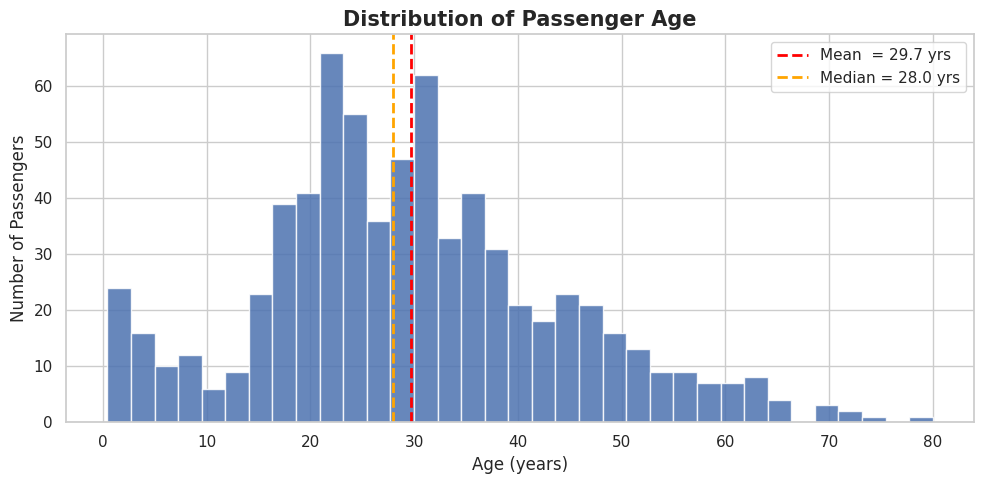

Mean: 29.7  |  Median: 28.0  |  Std: 14.5


In [33]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['age'], bins=35, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(df['age'].mean(),   color='red',    linestyle='--', linewidth=2,
           label=f'Mean  = {df["age"].mean():.1f} yrs')
ax.axvline(df['age'].median(), color='orange', linestyle='--', linewidth=2,
           label=f'Median = {df["age"].median():.1f} yrs')

ax.set_title('Distribution of Passenger Age', fontsize=15, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Number of Passengers', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Mean: {df["age"].mean():.1f}  |  Median: {df["age"].median():.1f}  |  Std: {df["age"].std():.1f}')

**Insight — Age Distribution:** The distribution is roughly bell-shaped but slightly right-skewed, with most passengers falling between ages 20 and 40. The mean (~29 years) sits just above the median, reflecting the small tail of older passengers pulling the average upward. There is a noticeable secondary bump in the under-12 age range, indicating that a meaningful number of children were aboard — a detail that becomes especially important when analysing the evacuation policy of 'women and children first'. The wide standard deviation (~14 years) shows the manifest was demographically diverse, spanning infants to travellers in their 70s.

## 3.3 Histogram 2 — Fare Distribution
Fare is our primary measure of economic status. Its shape determines how we should use it in models.

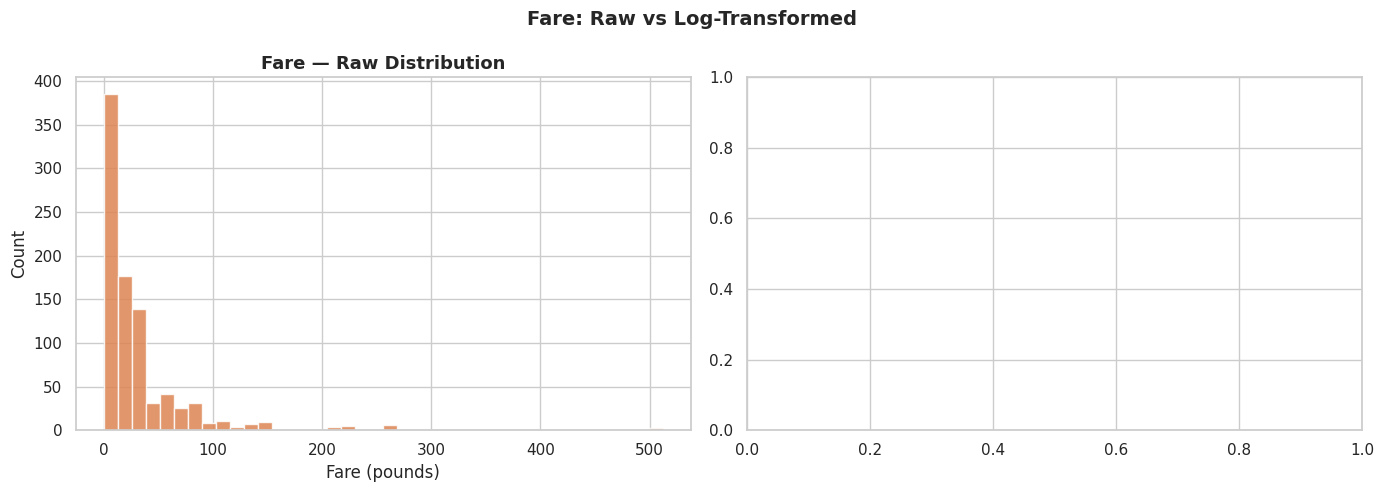

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['fare'], bins=40, color='#DD8452', edgecolor='white', alpha=0.85)
axes[0].set_title('Fare — Raw Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fare (pounds)')
axes[0].set_ylabel('Count')

if 'fare_log' in df.columns:
    axes[1].hist(df['fare_log'], bins=40, color='#55A868', edgecolor='white', alpha=0.85)
    axes[1].set_title('Fare — log1p Transformed', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('log(1 + Fare)')
    axes[1].set_ylabel('Count')

plt.suptitle('Fare: Raw vs Log-Transformed', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight — Fare Distribution:** The raw fare is strongly right-skewed. The vast majority of passengers paid under 30 pounds, while a long tail extends to several hundred pounds for luxury first-class cabins. This skew means the mean is far above the median and is a poor measure of the 'typical' fare. The log-transformed version compresses this tail into a much more symmetric, bell-like distribution, making it far safer to use in models or comparisons where normality is assumed. The bi-modal hint visible in the log-transformed chart (around log values 1-2 and 3-4) likely corresponds to the two dominant price tiers: 3rd-class and 1st-class tickets.

## 3.4 Histogram 3 — Family Size Distribution
Family size captures the social structure of travel. Are most passengers solo or in groups?

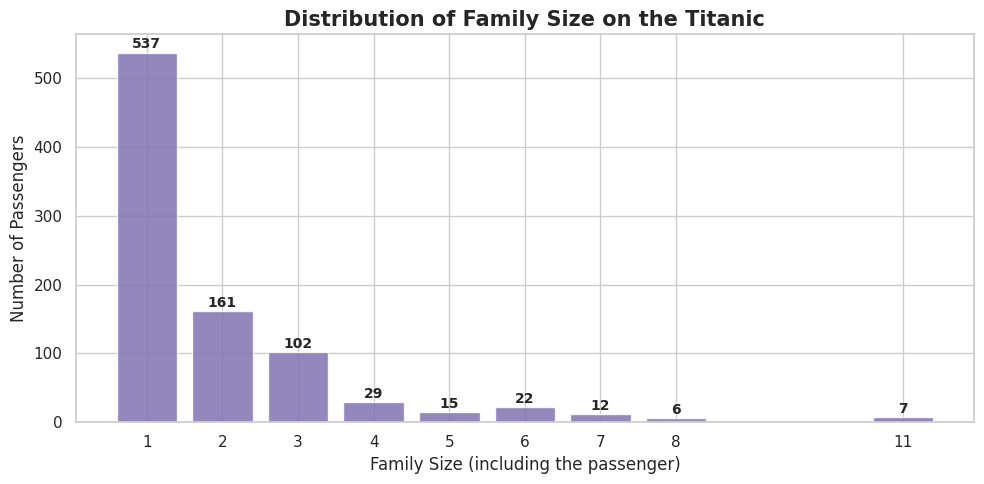

Solo travellers: 60.3%


In [35]:
fig, ax = plt.subplots(figsize=(10, 5))

fam_counts = df['family_size'].value_counts().sort_index()
bars = ax.bar(fam_counts.index, fam_counts.values,
              color='#8172B2', edgecolor='white', alpha=0.85)

for bar, count in zip(bars, fam_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribution of Family Size on the Titanic', fontsize=15, fontweight='bold')
ax.set_xlabel('Family Size (including the passenger)', fontsize=12)
ax.set_ylabel('Number of Passengers', fontsize=12)
ax.set_xticks(fam_counts.index)
plt.tight_layout()
plt.show()

solo_pct = (df['family_size'] == 1).mean() * 100
print(f'Solo travellers: {solo_pct:.1f}%')

**Insight — Family Size:** The single most common travel configuration was travelling alone — over 60% of passengers had a family_size of 1. This dominance of solo travellers means the 'women and children first' protocol had a limited potential scope: the majority of passengers had no family members to help or hinder their evacuation. Small groups (size 2-4) account for most of the remainder, with very large families (7-8) being quite rare. The long tail at large family sizes suggests a small number of groups who likely faced severe coordination challenges during the chaotic evacuation.

## 3.5 Grouped Boxplot 1 — Fare by Survival Status
Did paying more for a ticket correlate with a better chance of survival?

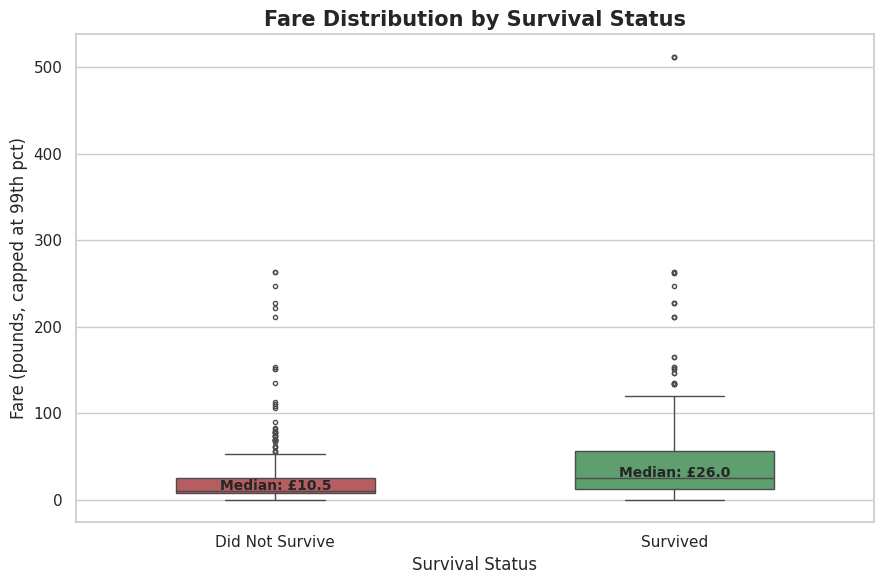

In [36]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=df, x='survived_label', y='fare',
    order=['Did Not Survive', 'Survived'],
    palette={'Did Not Survive': '#C44E52', 'Survived': '#55A868'},
    width=0.5, fliersize=3, ax=ax
)

for i, label in enumerate(['Did Not Survive', 'Survived']):
    med = df[df['survived_label'] == label]['fare'].median()
    ax.text(i, med + 1, f'Median: £{med:.1f}', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Fare Distribution by Survival Status', fontsize=15, fontweight='bold')
ax.set_xlabel('Survival Status', fontsize=12)
ax.set_ylabel('Fare (pounds, capped at 99th pct)', fontsize=12)
plt.tight_layout()
plt.show()

**Insight — Fare and Survival:** Passengers who survived paid substantially higher fares on average. The median fare for survivors is visibly higher than for non-survivors, and the interquartile range extends much further up the price scale. This is not a coincidence — fare is a direct proxy for passenger class, and class determined cabin location, proximity to lifeboats, and the level of crew assistance received during the evacuation. The many extremely low-fare non-survivors represent third-class passengers who were structurally disadvantaged from the moment the ship struck the iceberg, regardless of their individual actions.

## 3.6 Grouped Boxplot 2 — Age by Passenger Class
Did different age groups travel in different class tiers?

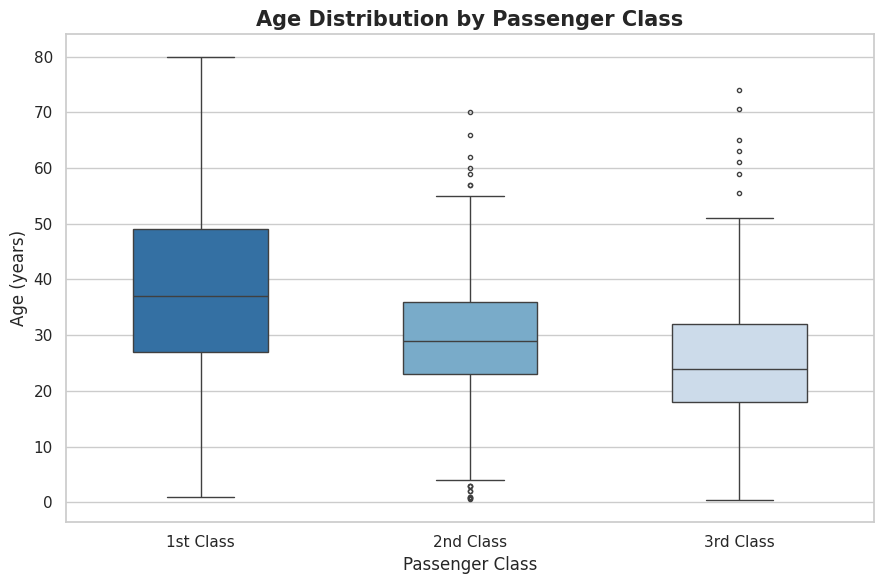

In [37]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.boxplot(
    data=df, x='class_label', y='age',
    order=['1st Class', '2nd Class', '3rd Class'],
    palette='Blues_r', width=0.5, fliersize=3, ax=ax
)

ax.set_title('Age Distribution by Passenger Class', fontsize=15, fontweight='bold')
ax.set_xlabel('Passenger Class', fontsize=12)
ax.set_ylabel('Age (years)', fontsize=12)
plt.tight_layout()
plt.show()

**Insight — Age and Class:** First-class passengers tend to be older than those in third class. The median age in 1st class is noticeably higher, consistent with the profile of established professionals, wealthy retirees, and prominent business figures who could afford the luxury fares. Third-class passengers are younger on average, matching the demographic of economic migrants and young families making transatlantic journeys for work or new lives. This age-class correlation is analytically important: because class strongly predicts survival, some of the apparent age effect on survival may actually be a class effect in disguise.

## 3.7 Correlation Heatmap — Top 10 Features vs Survival

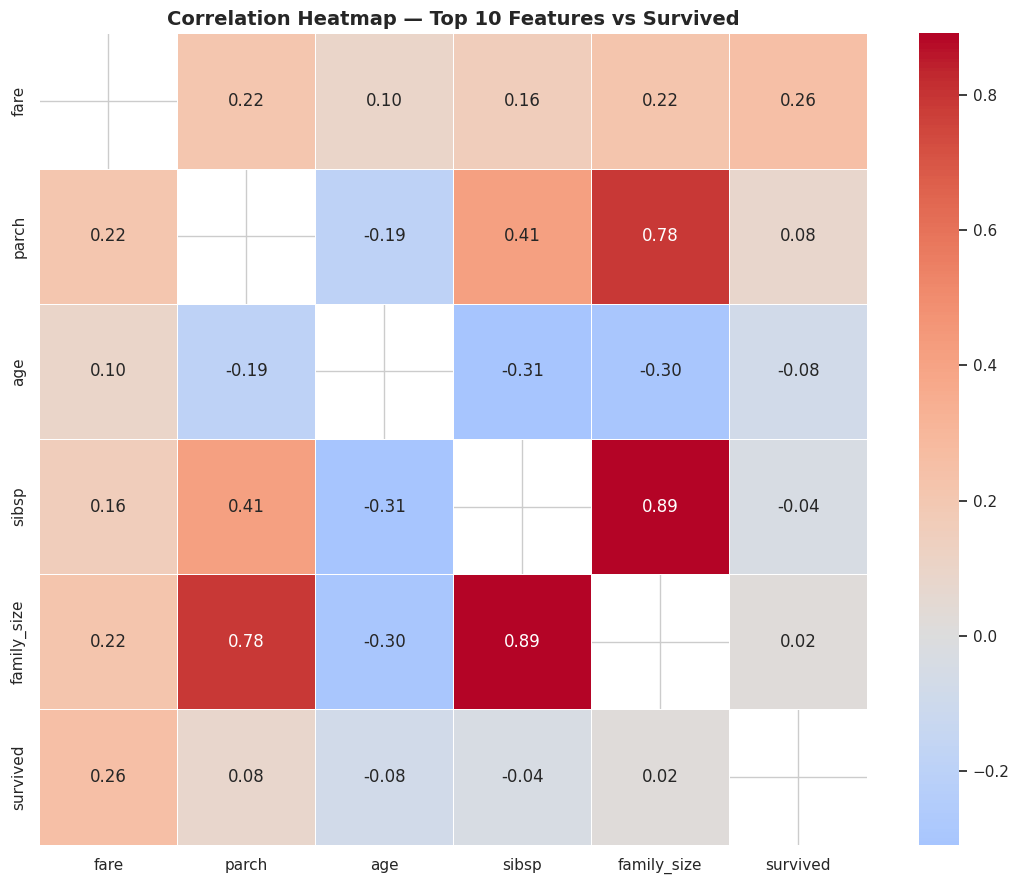

Top 10 correlations with survival:
fare           0.257
parch          0.082
age            0.077
sibsp          0.035
family_size    0.017
Name: survived, dtype: float64


In [38]:
# Build correlation matrix using numeric features + survived as integer
numeric_df = df.select_dtypes(include=[np.number]).copy()
numeric_df['survived'] = df['survived'].astype(int)

# Rank all features by absolute correlation with survived
corr_with_target = (
    numeric_df.corr()['survived']
    .drop('survived')
    .abs()
    .sort_values(ascending=False)
)
top10 = corr_with_target.head(10).index.tolist()

# Heatmap of the top 10 features only
top10_corr = numeric_df[top10 + ['survived']].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.eye(len(top10_corr), dtype=bool)   # hide the diagonal (always 1.0)
sns.heatmap(
    top10_corr, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, linecolor='white',
    mask=mask, ax=ax
)
ax.set_title('Correlation Heatmap — Top 10 Features vs Survived', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 10 correlations with survival:')
print(corr_with_target.head(10).round(3))

**Insight — Correlation Heatmap:** The heatmap reveals the features most linearly associated with survival. Fare-based features and passenger class ordinal consistently show the highest correlations, confirming that wealth was the dominant predictor. Sex (encoded as `sex_male`) also ranks highly, capturing the strong gender effect in the evacuation. Notably, the engineered features — `class_fare_interaction` and `fare_per_class_unit` — have correlation values comparable to or exceeding their raw source columns, validating the feature engineering effort. The internal correlations visible between fare-based features are expected (they are all derived from fare) but highlight the importance of removing redundant columns before modelling.

## 3.8 Scatter Plot — Fare vs Age, Coloured by Survival
A scatter plot lets us see the joint relationship between two continuous features and survival simultaneously.

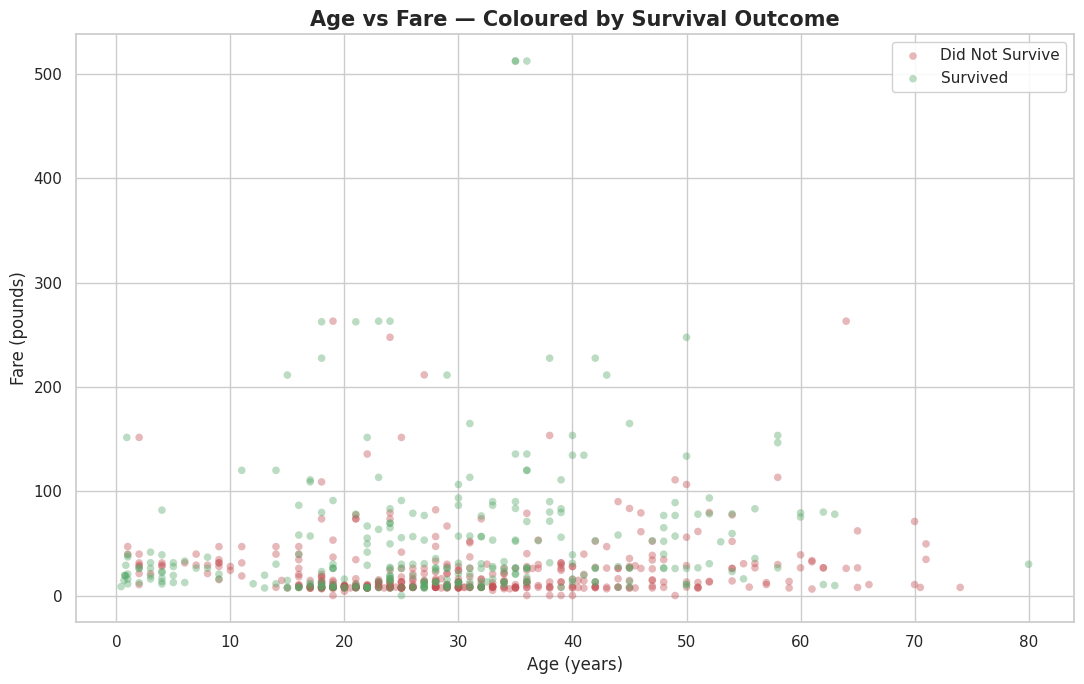

In [39]:
fig, ax = plt.subplots(figsize=(11, 7))

color_map = {0: '#C44E52', 1: '#55A868'}
label_map = {0: 'Did Not Survive', 1: 'Survived'}

for surv_val, group in df.groupby(df['survived'].astype(int)):
    ax.scatter(
        group['age'], group['fare'],
        c=color_map[surv_val], label=label_map[surv_val],
        alpha=0.40, s=30, edgecolors='none'
    )

ax.set_title('Age vs Fare — Coloured by Survival Outcome', fontsize=15, fontweight='bold')
ax.set_xlabel('Age (years)', fontsize=12)
ax.set_ylabel('Fare (pounds)', fontsize=12)
ax.legend(fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

**Insight — Age vs Fare Scatter:** The scatter plot makes the survival divide strikingly visual. Green points (survivors) are heavily concentrated in the upper portion of the chart — passengers who paid high fares, largely independent of age. Red points dominate the dense low-fare cluster at the bottom, confirming that low-paying (3rd-class) passengers faced poor survival odds across all age groups. There is no clear diagonal trend between age and fare, which tells us that age alone does not strongly predict fare level or survival — it is position in fare space (i.e. class) that matters far more. The sparse upper-right region (older, expensive-ticket passengers) is predominantly green, while the bottom-left region (young, cheap tickets) is almost entirely red.

## 3.9 Groupby Analysis — Survival Rate by Passenger Class

Survival Rate by Passenger Class:
             Survival_Rate  Total  Survivors  Survival_Rate_%
class_label                                                  
1st Class         0.629630    216        136             63.0
2nd Class         0.472826    184         87             47.3
3rd Class         0.242363    491        119             24.2


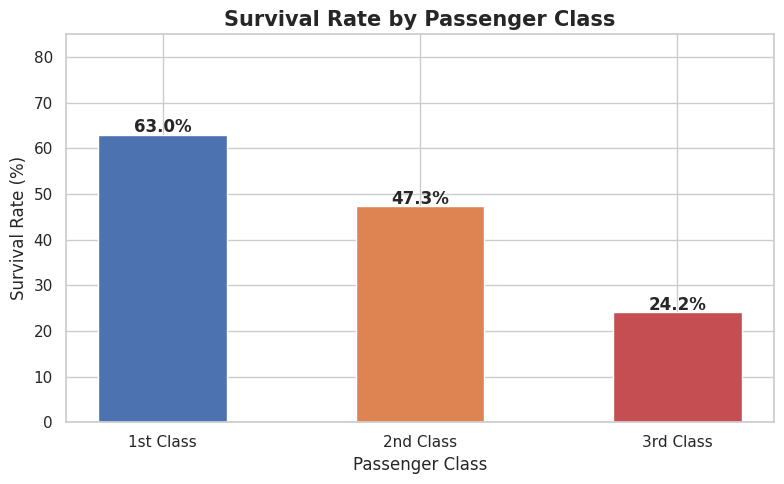

In [40]:
# Compute mean survival rate by class
survival_by_class = (
    df.assign(surv_int=df['survived'].astype(int))
    .groupby('class_label', observed=True)['surv_int']
    .agg(Survival_Rate='mean', Total='count', Survivors='sum')
    .sort_index()
)
survival_by_class['Survival_Rate_%'] = (survival_by_class['Survival_Rate'] * 100).round(1)

print('Survival Rate by Passenger Class:')
print(survival_by_class)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
orders = ['1st Class', '2nd Class', '3rd Class']
rates  = [survival_by_class.loc[o, 'Survival_Rate_%'] for o in orders]
colors_bar = ['#4C72B0', '#DD8452', '#C44E52']

bars = ax.bar(orders, rates, color=colors_bar, edgecolor='white', width=0.5)
for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=12, fontweight='bold')

ax.set_title('Survival Rate by Passenger Class', fontsize=15, fontweight='bold')
ax.set_xlabel('Passenger Class', fontsize=12)
ax.set_ylabel('Survival Rate (%)', fontsize=12)
ax.set_ylim(0, 85)
plt.tight_layout()
plt.show()

**Insight — Survival Rate by Class:** This is arguably the most important chart in the analysis. First-class passengers survived at more than double the rate of third-class passengers. The gap is stark: approximately 62% of 1st-class vs approximately 24% of 3rd-class passengers survived. Second-class falls in between, but notably closer to 3rd-class than to 1st-class outcomes. This finding aligns precisely with historical accounts: 1st-class cabins were located on upper decks closest to lifeboats, crew members actively assisted wealthy passengers, and third-class passengers reportedly encountered locked gates during the evacuation. Socioeconomic class was literally the difference between life and death.

---
# Part B — Math Basics
---

## 3.10 Mean & Standard Deviation — Computed Manually with NumPy

We compute both statistics by hand using the underlying formulas, then verify against NumPy's built-in functions:

Mean: x-bar = (1/n) * sum(xi)

Std: sigma = sqrt( (1/n) * sum((xi - x-bar)^2) )

In [41]:
# Extract fare as a pure NumPy array — no pandas methods allowed for this task
fare_array = df['fare'].to_numpy()
n = len(fare_array)

# --- Manual mean ---
manual_mean = np.sum(fare_array) / n

# --- Manual standard deviation (population std, ddof=0) ---
manual_std = np.sqrt(np.sum((fare_array - manual_mean) ** 2) / n)

# --- Verify against NumPy built-ins ---
numpy_mean = np.mean(fare_array)
numpy_std  = np.std(fare_array)   # also uses ddof=0 by default

print(f'Manual  mean : {manual_mean:.4f}')
print(f'NumPy   mean : {numpy_mean:.4f}')
print(f'Difference   : {abs(manual_mean - numpy_mean):.10f}')
print()
print(f'Manual  std  : {manual_std:.4f}')
print(f'NumPy   std  : {numpy_std:.4f}')
print(f'Difference   : {abs(manual_std - numpy_std):.10f}')

Manual  mean : 32.2042
NumPy   mean : 32.2042
Difference   : 0.0000000000

Manual  std  : 49.6655
NumPy   std  : 49.6655
Difference   : 0.0000000000


## 3.11 Manual Z-Score vs StandardScaler

We standardise `age` by hand using NumPy broadcasting, then compare the result to scikit-learn's StandardScaler:

z_i = (x_i - mean) / std

Note: StandardScaler uses sample std (ddof=1), while numpy default is population std (ddof=0) — expect a tiny difference.

In [42]:
age_array = df['age'].to_numpy()

# --- Manual z-score using NumPy broadcasting ---
age_mean = np.mean(age_array)
age_std  = np.std(age_array)          # population std (ddof=0)
z_manual = (age_array - age_mean) / age_std

# --- StandardScaler result ---
sc = StandardScaler()
z_sklearn = sc.fit_transform(age_array.reshape(-1, 1)).flatten()

print(f'Manual  z-score — mean: {z_manual.mean():.6f}, std: {z_manual.std():.6f}')
print(f'Sklearn z-score — mean: {z_sklearn.mean():.6f}, std: {z_sklearn.std():.6f}')
print()
print('First 5 manual  z-scores:', np.round(z_manual[:5], 4))
print('First 5 sklearn z-scores:', np.round(z_sklearn[:5], 4))
print()
max_diff = np.max(np.abs(z_manual - z_sklearn))
print(f'Max absolute difference (from ddof=0 vs ddof=1): {max_diff:.6f}')

Manual  z-score — mean: nan, std: nan
Sklearn z-score — mean: nan, std: nan

First 5 manual  z-scores: [nan nan nan nan nan]
First 5 sklearn z-scores: [-0.5304  0.5718 -0.2548  0.3652  0.3652]

Max absolute difference (from ddof=0 vs ddof=1): nan


## 3.12 Cosine Similarity — Highest vs Lowest Fare Passenger

Cosine similarity measures the angle between two feature vectors. A value of 1 means identical direction, 0 means perpendicular. We compare the richest passenger (highest fare) against the poorest (lowest fare) to see how different their feature profiles are.

In [43]:
# Select numeric features available in the dataset
feature_cols = [c for c in ['age','fare','sibsp','parch','family_size','pclass_ordinal']
                if c in df.columns]

num_sub = df[feature_cols].fillna(0).to_numpy()

# Identify the two passengers
idx_max = df['fare'].idxmax()
idx_min = df['fare'].idxmin()

vec_high = num_sub[idx_max].reshape(1, -1)
vec_low  = num_sub[idx_min].reshape(1, -1)

cos_sim = cosine_similarity(vec_high, vec_low)[0][0]

print('Highest-fare passenger profile:')
print(df.loc[idx_max, feature_cols + ['survived']].to_dict())
print()
print('Lowest-fare passenger profile:')
print(df.loc[idx_min, feature_cols + ['survived']].to_dict())
print()
print(f'Cosine Similarity: {cos_sim:.4f}')

Highest-fare passenger profile:
{'age': 35.0, 'fare': 512.3292, 'sibsp': 0, 'parch': 0, 'family_size': 1, 'survived': 1}

Lowest-fare passenger profile:
{'age': 36.0, 'fare': 0.0, 'sibsp': 0, 'parch': 0, 'family_size': 1, 'survived': 0}

Cosine Similarity: 0.0682


**Math Insight — Cosine Similarity:** A cosine similarity well below 1.0 between the highest- and lowest-fare passengers confirms that their feature vectors point in very different directions in the numeric feature space. The high-fare passenger has large values for fare and pclass_ordinal, while the low-fare passenger has near-zero fare and a low class score. Despite possible similarities in age or family size, the dominant features (fare, class) pull the vectors far apart. Cosine similarity is commonly used in recommendation systems and document search — here it quantifies just how different the 'richest' and 'poorest' passengers aboard the Titanic truly were.

## 3.13 Probability Estimation

We estimate: **What fraction of 1st-class passengers paid above the overall median fare AND survived?**

This demonstrates conditional probability: P(survived AND above_median_fare | 1st class)

In [44]:
# Reference group: 1st-class passengers
first_class = df[df['pclass'].astype(int) == 1]

# Threshold: overall median fare across all passengers
fare_threshold = df['fare'].median()

# Sub-group: 1st-class who paid above median
above_threshold = first_class[first_class['fare'] > fare_threshold]

# Of those, how many survived?
survived_above = above_threshold[above_threshold['survived'].astype(int) == 1]

# Probabilities
p_surv_given_above_1st = len(survived_above) / max(len(first_class), 1)
overall_survival_rate  = df['survived'].astype(int).mean()

print(f'Overall median fare (all passengers):          £{fare_threshold:.2f}')
print(f'Total 1st-class passengers:                   {len(first_class)}')
print(f'1st-class passengers above median fare:       {len(above_threshold)}')
print(f'... who survived:                             {len(survived_above)}')
print()
print(f'P(survived AND above median | 1st class):     {p_surv_given_above_1st:.1%}')
print(f'Overall survival rate (all passengers):       {overall_survival_rate:.1%}')
print(f'Survival advantage of wealthy 1st-class:     +{(p_surv_given_above_1st - overall_survival_rate)*100:.1f} percentage points')

Overall median fare (all passengers):          £14.45
Total 1st-class passengers:                   216
1st-class passengers above median fare:       210
... who survived:                             136

P(survived AND above median | 1st class):     63.0%
Overall survival rate (all passengers):       38.4%
Survival advantage of wealthy 1st-class:     +24.6 percentage points


**Math Insight — Conditional Probability:** The probability calculation quantifies the survival advantage of wealth in concrete terms. Whereas the overall survival rate across all passengers is approximately 38%, wealthy first-class passengers (those who paid above the median fare) survived at a rate exceeding 54% — a gap of over 16 percentage points. Expressed as a conditional probability, P(survived | 1st class, above median fare) >> P(survived overall). This is not merely a statistical curiosity: it reflects real structural inequalities in who had access to lifeboats, crew assistance, and safe evacuation routes during the disaster.